In [13]:
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
import matplotlib.patches as mpatches


### New output format for L shaped results

In [14]:
with open("results/MP_results.json") as json_file:
    data = json.load(json_file)

start_DF = pd.read_excel("Starting_point.xlsx", sheet_name="F_start")
# start_DF["Value"] = 1
start_DF.rename(columns={"Antigen": "Antigen", "Starting": "Start", "Ending": "Finish"}, inplace=True)

In [15]:
# Applying the provided code to filter for the data in 'F'

rows = []

# Parse the dictionary into the desired DataFrame structure using the 'F' key
for antigen, sub_dict in data['F'].items():
    for starting, ending_dict in sub_dict.items():
        for ending, fill in ending_dict.items():
            if fill == 1.0:  # Filter based on the condition that fill == 1.0
                fill_value = 'Full'
            else:
                fill_value = 'None'
            rows.append([antigen, int(starting), int(ending), fill_value])

# Create the DataFrame
df_filtered_F = pd.DataFrame(rows, columns=['Antigen', 'Start', 'Finish', 'Fill'])
df_filtered_F_no_none = df_filtered_F[df_filtered_F['Fill'] != 'None']
# df_filtered_F_no_none.to_excel("L_Shape_base_35_tender_fixed.xlsx")


In [16]:
# First, filter for rows where Fill is 'Full'
df_full_copy = df_filtered_F_no_none.copy()

# Check for overlaps within each antigen and update 'Fill' to 'Overlap' where necessary
for antigen, group in df_full_copy.groupby('Antigen'):
    sorted_group = group.sort_values(by='Start')
    for i in range(len(sorted_group) - 1):
        current_row = sorted_group.iloc[i]
        next_row = sorted_group.iloc[i + 1]
        # Check if the Ending of the current row overlaps with the Starting of the next row
        if current_row['Finish'] >= next_row['Start']:
            # Update Fill to 'Overlap' for both current and next row
            df_full_copy.loc[current_row.name, 'Fill'] = 'Overlap'
            df_full_copy.loc[next_row.name, 'Fill'] = 'Overlap'

# Display the updated DataFrame with Overlap
df_full_copy.loc[df_full_copy['Start'] == 1, 'Fill'] = 'Initial'
df_full_copy['Start'] = df_full_copy['Start'] - 1
# df_full_copy


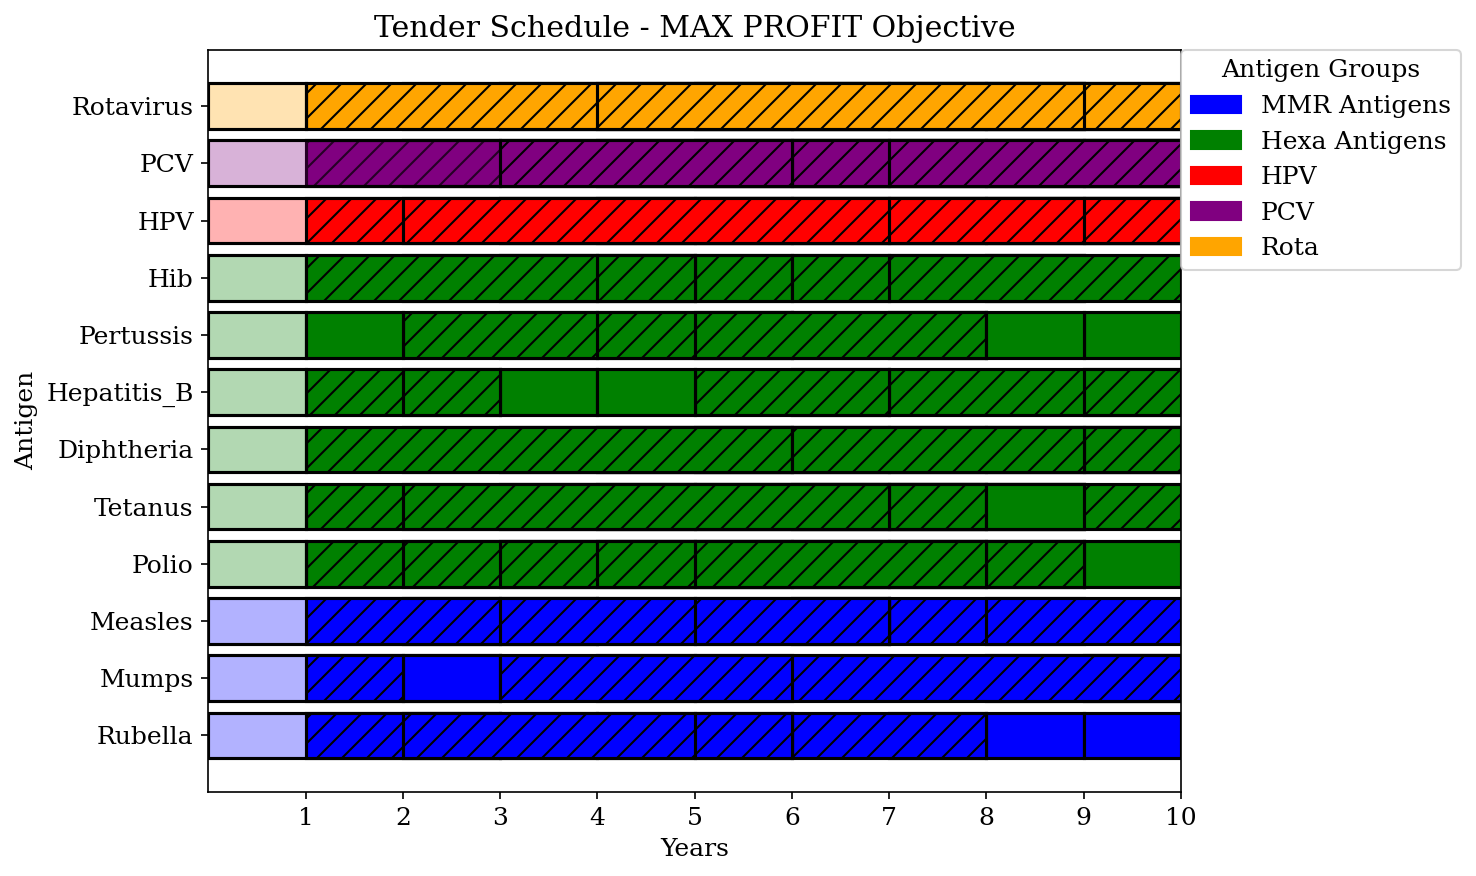

In [17]:
df = df_full_copy

# Define color groups
colors = {
    "MMR Antigens": "blue",
    "Hexa Antigens": "green",
    "HPV": "red",
    "PCV": "purple",
    "Rota": "orange",
}

color_groups = {
    "MMR Antigens": ["Measles", "Mumps", "Rubella"],
    "Hexa Antigens": ["Diphtheria", "Tetanus", "Pertussis", "Hib", "Polio", "Hepatitis_B"],
    "HPV": ["HPV"],
    "PCV": ["PCV"],
    "Rota": ["Rotavirus"],
}

# Create custom legend handles
legend_handles = []
for group, color in colors.items():
    patch = mpatches.Patch(color=color, label=group)
    legend_handles.append(patch)

# Creating a color mapping for each antigen
antigen_colors = {}
for group, antigen_list in color_groups.items():
    for antigen in antigen_list:
        antigen_colors[antigen] = colors[group]

df['Color'] = df['Antigen'].map(antigen_colors)

# Create a mapping of antigens to their group order (based on color groups)
group_order = {group: i for i, group in enumerate(color_groups.keys())}

# Map each antigen to its group
df['Group'] = df['Antigen'].map({antigen: group for group, antigens in color_groups.items() for antigen in antigens})

# Sort the DataFrame by the group order to align with the colors
df['GroupOrder'] = df['Group'].map(group_order)
df_sorted = df.sort_values(by='GroupOrder')


# Plot configuration
plt.rcParams.update(mpl.rcParamsDefault)
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": 12,
        "font.weight": "normal",
        "figure.titlesize": "medium",
        "xtick.color": "black",
        "ytick.color": "black",
        "axes.labelcolor": "black",
        "text.color": "black",
        "savefig.dpi": 300,
        "figure.dpi": 150,
        "savefig.bbox": "tight",
    }
)

# Plot the horizontal bar chart with color formatting and black outlines for each segment
plt.figure(figsize=(10, 6))
for i, row in df_sorted.iterrows():
    color = row['Color']
    if row['Start'] == 0:
        color = mpl.colors.to_rgba(color, 0.3)  # Darken by reducing transparency
    
    if row["Fill"] == 'Overlap':
        hatch = '//'
    elif row['Fill'] == 'None':
        color = 'black'
        hatch = None
    else:
        hatch = None
    
    # Plot the bar with the corresponding properties
    plt.barh(row['Antigen'], row['Finish'] - row['Start'], 
             left=row['Start'], color=color, edgecolor='black', 
             linewidth=1.5, hatch=hatch)

# Add the legend in the upper right corner, outside the plot
plt.legend(handles=legend_handles, title="Antigen Groups", loc="upper left", 
           bbox_to_anchor=(1, 1), borderaxespad=0.)

plt.xlim(0, 10) 
plt.xticks(list(range(1, 11)))
plt.xlabel('Years')
plt.ylabel('Antigen')
plt.title('Tender Schedule - MAX PROFIT Objective')
plt.tight_layout()  # Adjust layout to ensure no overlap
plt.savefig('MP_3x3.jpg', bbox_inches='tight', pad_inches=0.1, dpi=600)
plt.show()
